In [1]:
import os
import json
import math
import copy

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

In [2]:
with open("data_split.json", "r") as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 1000
Validation: 125
Test: 126


In [3]:
train_data = r"Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [4]:
def preprocess_t2f(image):
    if image.shape != (240, 240, 155):
        raise ValueError(
            f"Unexpected image shape: {image.shape}"
        )

    # Crop to 208 x 224 x 155
    image = image[16:224, 8:232, :]

    # Pad depth to 160
    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    # Exact original BraTS foreground mask
    foreground = image > 0

    if not np.any(foreground):
        raise ValueError(
            "No foreground voxels found"
        )

    upper = np.percentile(
        image[foreground],
        99.9
    )

    image = np.clip(
        image,
        0,
        upper
    )

    # [0,1]
    image = image / upper

    # [-1,1]
    image = (
        image * 2.0
        - 1.0
    )

    # True air background
    image[~foreground] = -1.0

    return (
        image.astype(np.float32),
        foreground.astype(np.float32)
    )

In [5]:
class BraTSDataset(Dataset):
    def __init__(
        self,
        subjects,
        data_dir
    ):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):

        subject = self.subjects[idx]

        subject_path = os.path.join(
            self.data_dir,
            subject
        )

        files = os.listdir(
            subject_path
        )

        t2f_files = [
            f for f in files
            if "t2f" in f.lower()
        ]

        if len(t2f_files) == 0:
            raise FileNotFoundError(
                f"No T2f file found for {subject}"
            )

        image = nib.load(
            os.path.join(
                subject_path,
                t2f_files[0]
            )
        ).get_fdata()

        image, foreground_mask = (
            preprocess_t2f(image)
        )

        image = torch.from_numpy(
            image
        ).unsqueeze(0)

        foreground_mask = (
            torch.from_numpy(
                foreground_mask
            )
            .unsqueeze(0)
            .bool()
        )

        return {
            "image": image,
            "foreground_mask":
                foreground_mask,
            "subject": subject
        }

In [6]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))

Dataset size: 1000


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(
    "Number of training batches:",
    len(train_loader)
)

Number of training batches: 1000


In [8]:
timesteps = 1000


def cosine_beta_schedule(
    timesteps,
    s=0.008
):
    steps = timesteps + 1

    x = torch.linspace(
        0,
        timesteps,
        steps,
        dtype=torch.float64
    )

    alpha_bar = torch.cos(
        (
            (x / timesteps + s)
            / (1 + s)
        )
        * math.pi
        * 0.5
    ) ** 2

    alpha_bar = (
        alpha_bar
        / alpha_bar[0]
    )

    betas = (
        1.0
        - (
            alpha_bar[1:]
            / alpha_bar[:-1]
        )
    )

    return torch.clamp(
        betas,
        min=1e-8,
        max=0.999
    ).float()


def rescale_zero_terminal_snr(
    betas
):
    """
    Algorithm 1 from:
    'Common Diffusion Noise Schedules
    and Sample Steps are Flawed'

    Rescales beta schedule so that
    alpha_bar_T = 0 exactly.
    """

    alphas = (
        1.0 - betas
    )

    alphas_cumprod = torch.cumprod(
        alphas,
        dim=0
    )

    alpha_bar_sqrt = torch.sqrt(
        alphas_cumprod
    )

    alpha_bar_sqrt_0 = (
        alpha_bar_sqrt[0].clone()
    )

    alpha_bar_sqrt_T = (
        alpha_bar_sqrt[-1].clone()
    )

    # Shift terminal value to zero
    alpha_bar_sqrt = (
        alpha_bar_sqrt
        - alpha_bar_sqrt_T
    )

    # Preserve initial value
    alpha_bar_sqrt = (
        alpha_bar_sqrt
        * alpha_bar_sqrt_0
        / (
            alpha_bar_sqrt_0
            - alpha_bar_sqrt_T
        )
    )

    alpha_bar = (
        alpha_bar_sqrt ** 2
    )

    new_alphas = (
        alpha_bar[1:]
        / alpha_bar[:-1]
    )

    new_alphas = torch.cat(
        [
            alpha_bar[0:1],
            new_alphas
        ]
    )

    new_betas = (
        1.0 - new_alphas
    )

    return new_betas.float()


# Original cosine schedule
betas = cosine_beta_schedule(
    timesteps
)

# V5: force terminal SNR to exactly zero
betas = rescale_zero_terminal_snr(
    betas
)


alphas = (
    1.0 - betas
)

alphas_cumprod = torch.cumprod(
    alphas,
    dim=0
)

alphas_cumprod_prev = F.pad(
    alphas_cumprod[:-1],
    (1, 0),
    value=1.0
)


sqrt_alphas_cumprod = torch.sqrt(
    alphas_cumprod
)

sqrt_one_minus_alphas_cumprod = (
    torch.sqrt(
        1.0
        - alphas_cumprod
    )
)


posterior_variance = (
    betas
    * (
        1.0
        - alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)

posterior_variance = torch.clamp(
    posterior_variance,
    min=1e-20
)


posterior_mean_coef1 = (
    betas
    * torch.sqrt(
        alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)


posterior_mean_coef2 = (
    (
        1.0
        - alphas_cumprod_prev
    )
    * torch.sqrt(
        alphas
    )
    / (
        1.0
        - alphas_cumprod
    )
)


snr = (
    alphas_cumprod
    / torch.clamp(
        1.0
        - alphas_cumprod,
        min=1e-12
    )
)


print(
    "Beta range:",
    betas.min().item(),
    betas.max().item()
)

print(
    "Initial alpha_cumprod:",
    alphas_cumprod[0].item()
)

print(
    "Final alpha_cumprod:",
    alphas_cumprod[-1].item()
)

print(
    "Final SNR:",
    snr[-1].item()
)


assert (
    alphas_cumprod[-1].item()
    == 0.0
)

print(
    "Zero-terminal-SNR check passed."
)

Beta range: 4.124641418457031e-05 1.0
Initial alpha_cumprod: 0.9999587535858154
Final alpha_cumprod: 0.0
Final SNR: 0.0
Zero-terminal-SNR check passed.


In [9]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(
        self,
        dim
    ):
        super().__init__()

        self.dim = dim

    def forward(self, t):

        device = t.device

        half_dim = (
            self.dim // 2
        )

        embedding_scale = (
            math.log(10000)
            / (half_dim - 1)
        )

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embedding_scale
        )

        embeddings = (
            t[:, None].float()
            * embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

In [10]:
class ResBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=in_channels
        )

        self.conv1 = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                time_dim,
                out_channels * 2
            )
        )

        # V5:
        # Start scale = 0 and shift = 0
        nn.init.zeros_(
            self.time_mlp[-1].weight
        )

        nn.init.zeros_(
            self.time_mlp[-1].bias
        )


        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.conv2 = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        # Start residual branch near zero
        nn.init.zeros_(
            self.conv2.weight
        )

        nn.init.zeros_(
            self.conv2.bias
        )


        if in_channels != out_channels:
            self.residual = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual = nn.Identity()


    def forward(
        self,
        x,
        t
    ):
        residual = self.residual(
            x
        )

        h = self.norm1(
            x
        )

        h = F.silu(
            h
        )

        h = self.conv1(
            h
        )

        time_emb = self.time_mlp(
            t
        )

        scale, shift = (
            time_emb.chunk(
                2,
                dim=1
            )
        )

        scale = scale[
            :,
            :,
            None,
            None,
            None
        ]

        shift = shift[
            :,
            :,
            None,
            None,
            None
        ]

        h = self.norm2(
            h
        )

        h = (
            h
            * (
                1.0 + scale
            )
            + shift
        )

        h = F.silu(
            h
        )

        h = self.dropout(
            h
        )

        h = self.conv2(
            h
        )

        return (
            h + residual
        )

In [11]:
class DownBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):
        super().__init__()

        self.resblock1 = ResBlock3D(
            in_channels,
            out_channels,
            time_dim
        )

        self.resblock2 = ResBlock3D(
            out_channels,
            out_channels,
            time_dim
        )

        self.downsample = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(
        self,
        x,
        t
    ):
        x = self.resblock1(
            x,
            t
        )

        x = self.resblock2(
            x,
            t
        )

        skip = x

        x = self.downsample(
            x
        )

        return skip, x


class UpBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        time_dim
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.resblock1 = ResBlock3D(
            out_channels
            + skip_channels,
            out_channels,
            time_dim
        )

        self.resblock2 = ResBlock3D(
            out_channels,
            out_channels,
            time_dim
        )

    def forward(
        self,
        x,
        skip,
        t
    ):
        x = self.upsample(
            x
        )

        if x.shape[2:] != skip.shape[2:]:
            raise ValueError(
                f"Upsample shape {x.shape} "
                f"does not match skip {skip.shape}"
            )

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.resblock1(
            x,
            t
        )

        x = self.resblock2(
            x,
            t
        )

        return x

In [12]:
class AttentionBlock3D(nn.Module):
    def __init__(
        self,
        channels,
        num_heads=4
    ):
        super().__init__()

        if channels % num_heads != 0:
            raise ValueError(
                "channels must be divisible "
                "by num_heads"
            )

        self.norm = nn.GroupNorm(
            num_groups=8,
            num_channels=channels
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):

        b, c, d, h, w = x.shape

        residual = x

        x = self.norm(
            x
        )

        # [B,C,D,H,W]
        # ->
        # [B,D*H*W,C]
        x = (
            x.permute(
                0,
                2,
                3,
                4,
                1
            )
            .reshape(
                b,
                d * h * w,
                c
            )
        )

        x, _ = self.attention(
            x,
            x,
            x,
            need_weights=False
        )

        # Restore 3D shape
        x = (
            x.reshape(
                b,
                d,
                h,
                w,
                c
            )
            .permute(
                0,
                4,
                1,
                2,
                3
            )
            .contiguous()
        )

        return x + residual


class UNet3D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=16,
        time_dim=256
    ):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(
                time_dim
            ),
            nn.Linear(
                time_dim,
                time_dim
            ),
            nn.SiLU(),
            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # 208 x 224 x 160
        self.input_conv = nn.Conv3d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # 208x224x160 -> 104x112x80
        self.down1 = DownBlock3D(
            base_channels,
            base_channels * 2,
            time_dim
        )

        # 104x112x80 -> 52x56x40
        self.down2 = DownBlock3D(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        # 52x56x40 -> 26x28x20
        self.down3 = DownBlock3D(
            base_channels * 4,
            base_channels * 8,
            time_dim
        )

        # 26x28x20 -> 13x14x10
        self.down4 = DownBlock3D(
            base_channels * 8,
            base_channels * 16,
            time_dim
        )

        # Bottleneck: 13 x 14 x 10
        self.mid1 = ResBlock3D(
            base_channels * 16,
            base_channels * 16,
            time_dim
        )

        self.mid_attention = AttentionBlock3D(
            base_channels * 16,
            num_heads=4
        )

        self.mid2 = ResBlock3D(
            base_channels * 16,
            base_channels * 16,
            time_dim
        )

        # 13x14x10 -> 26x28x20
        self.up4 = UpBlock3D(
            in_channels=base_channels * 16,
            skip_channels=base_channels * 16,
            out_channels=base_channels * 8,
            time_dim=time_dim
        )

        # 26x28x20 -> 52x56x40
        self.up3 = UpBlock3D(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 4,
            time_dim=time_dim
        )

        # 52x56x40 -> 104x112x80
        self.up2 = UpBlock3D(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 2,
            time_dim=time_dim
        )

        # 104x112x80 -> 208x224x160
        self.up1 = UpBlock3D(
            in_channels=base_channels * 2,
            skip_channels=base_channels * 2,
            out_channels=base_channels,
            time_dim=time_dim
        )

        self.output_norm = nn.GroupNorm(
            num_groups=8,
            num_channels=base_channels
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        # Start final noise-prediction layer near zero
        nn.init.zeros_(
            self.output_conv.weight
        )

        nn.init.zeros_(
            self.output_conv.bias
        )

    def forward(
        self,
        x,
        t
    ):
        t = self.time_embedding(
            t
        )

        x = self.input_conv(
            x
        )

        skip1, x = self.down1(
            x,
            t
        )

        skip2, x = self.down2(
            x,
            t
        )

        skip3, x = self.down3(
            x,
            t
        )

        skip4, x = self.down4(
            x,
            t
        )

        x = self.mid1(
            x,
            t
        )

        x = self.mid_attention(
            x
        )

        x = self.mid2(
            x,
            t
        )

        x = self.up4(
            x,
            skip4,
            t
        )

        x = self.up3(
            x,
            skip3,
            t
        )

        x = self.up2(
            x,
            skip2,
            t
        )

        x = self.up1(
            x,
            skip1,
            t
        )

        x = self.output_norm(
            x
        )

        x = F.silu(
            x
        )

        x = self.output_conv(
            x
        )

        return x

In [13]:
def q_sample(
    x0,
    t,
    noise=None
):
    if noise is None:
        noise = torch.randn_like(
            x0
        )

    device = x0.device

    sqrt_alpha = (
        sqrt_alphas_cumprod
        .to(device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    sqrt_one_minus_alpha = (
        sqrt_one_minus_alphas_cumprod
        .to(device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    xt = (
        sqrt_alpha
        * x0
        +
        sqrt_one_minus_alpha
        * noise
    )

    return xt, noise


def get_v_target(
    x0,
    noise,
    t
):
    device = x0.device

    sqrt_alpha = (
        sqrt_alphas_cumprod
        .to(device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    sqrt_one_minus_alpha = (
        sqrt_one_minus_alphas_cumprod
        .to(device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    v_target = (
        sqrt_alpha
        * noise
        -
        sqrt_one_minus_alpha
        * x0
    )

    return v_target

In [14]:
class EMA:
    def __init__(
        self,
        model,
        decay=0.9999
    ):
        self.decay = decay

        self.ema_model = copy.deepcopy(
            model
        )

        self.ema_model.eval()

        for parameter in (
            self.ema_model.parameters()
        ):
            parameter.requires_grad = False


    @torch.no_grad()
    def update(
        self,
        model
    ):
        ema_parameters = dict(
            self.ema_model.named_parameters()
        )

        model_parameters = dict(
            model.named_parameters()
        )

        for name, parameter in (
            model_parameters.items()
        ):
            ema_parameters[name].mul_(
                self.decay
            ).add_(
                parameter,
                alpha=(
                    1.0
                    - self.decay
                )
            )

        ema_buffers = dict(
            self.ema_model.named_buffers()
        )

        model_buffers = dict(
            model.named_buffers()
        )

        for name, buffer in (
            model_buffers.items()
        ):
            ema_buffers[name].copy_(
                buffer
            )


def train_ddpm(
    model,
    ema,
    train_loader,
    epochs,
    optimizer,
    device,
    start_epoch=0,
    checkpoint_dir=(
        "ddpm_v5_checkpoints"
    ),
    foreground_lambda=0.5
):
    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    loss_history_path = os.path.join(
        checkpoint_dir,
        "ddpm_v5_loss_history.npy"
    )

    if (
        start_epoch > 0
        and os.path.exists(
            loss_history_path
        )
    ):
        loss_history = (
            np.load(
                loss_history_path
            )
            .tolist()
        )
    else:
        loss_history = []


    use_amp = (
        device.type == "cuda"
    )

    scaler = (
        torch.cuda.amp.GradScaler(
            enabled=use_amp
        )
    )


    for epoch in range(
        start_epoch,
        epochs
    ):
        model.train()

        epoch_total_loss = 0.0
        epoch_global_loss = 0.0
        epoch_fg_loss = 0.0


        for batch_idx, batch in enumerate(
            train_loader
        ):
            x0 = batch["image"].to(
                device,
                non_blocking=True
            )

            foreground_mask = (
                batch[
                    "foreground_mask"
                ]
                .to(
                    device,
                    non_blocking=True
                )
            )


            t = torch.randint(
                low=0,
                high=timesteps,
                size=(
                    x0.shape[0],
                ),
                device=device,
                dtype=torch.long
            )


            noise = torch.randn_like(
                x0
            )


            xt, _ = q_sample(
                x0=x0,
                t=t,
                noise=noise
            )


            v_target = get_v_target(
                x0=x0,
                noise=noise,
                t=t
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            with torch.cuda.amp.autocast(
                enabled=use_amp
            ):
                v_pred = model(
                    xt,
                    t
                )


                squared_error = (
                    v_pred
                    - v_target
                ) ** 2


                # Global loss:
                # preserves background + brain boundary
                global_loss = (
                    squared_error.mean()
                )


                # Brain-foreground auxiliary loss:
                # prevents 81.7% air background
                # from dominating optimisation
                fg_error = (
                    squared_error[
                        foreground_mask
                    ]
                )

                foreground_loss = (
                    fg_error.mean()
                )


                loss = (
                    global_loss
                    +
                    foreground_lambda
                    * foreground_loss
                )


            scaler.scale(
                loss
            ).backward()


            scaler.unscale_(
                optimizer
            )


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )


            scaler.step(
                optimizer
            )

            scaler.update()


            ema.update(
                model
            )


            epoch_total_loss += (
                loss.item()
            )

            epoch_global_loss += (
                global_loss.item()
            )

            epoch_fg_loss += (
                foreground_loss.item()
            )


            if (
                batch_idx + 1
            ) % 10 == 0:

                print(
                    f"Epoch "
                    f"{epoch + 1}/{epochs} | "
                    f"Batch "
                    f"{batch_idx + 1}/"
                    f"{len(train_loader)} | "
                    f"Total="
                    f"{loss.item():.6f} | "
                    f"Global="
                    f"{global_loss.item():.6f} | "
                    f"FG="
                    f"{foreground_loss.item():.6f}"
                )


        avg_total_loss = (
            epoch_total_loss
            / len(train_loader)
        )

        avg_global_loss = (
            epoch_global_loss
            / len(train_loader)
        )

        avg_fg_loss = (
            epoch_fg_loss
            / len(train_loader)
        )


        loss_history.append(
            [
                avg_total_loss,
                avg_global_loss,
                avg_fg_loss
            ]
        )


        print(
            f"Epoch {epoch + 1} completed | "
            f"Total={avg_total_loss:.6f} | "
            f"Global={avg_global_loss:.6f} | "
            f"FG={avg_fg_loss:.6f}"
        )


        checkpoint_path = os.path.join(
            checkpoint_dir,
            (
                f"ddpm_v5_epoch_"
                f"{epoch + 1:03d}.pt"
            )
        )


        save_checkpoint(
            model=model,
            ema=ema,
            optimizer=optimizer,
            epoch=epoch + 1,
            path=checkpoint_path
        )


        np.save(
            loss_history_path,
            np.asarray(
                loss_history,
                dtype=np.float32
            )
        )


        print(
            "Saved:",
            checkpoint_path
        )

In [15]:
def save_checkpoint(
    model,
    ema,
    optimizer,
    epoch,
    path
):
    torch.save(
        {
            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "ema_state_dict":
                ema.ema_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict()
        },
        path
    )


def load_checkpoint(
    model,
    ema,
    optimizer,
    path,
    device
):
    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    ema.ema_model.load_state_dict(
        checkpoint[
            "ema_state_dict"
        ]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )

    return checkpoint["epoch"]

In [16]:
@torch.no_grad()
def sample_ddpm(
    model,
    shape,
    device
):
    model.eval()

    # Inference starts from pure Gaussian noise
    # at the actual final training timestep
    x = torch.randn(
        shape,
        device=device
    )


    sqrt_alpha_bar = (
        sqrt_alphas_cumprod
        .to(device)
    )

    sqrt_one_minus_alpha_bar = (
        sqrt_one_minus_alphas_cumprod
        .to(device)
    )

    coef1 = (
        posterior_mean_coef1
        .to(device)
    )

    coef2 = (
        posterior_mean_coef2
        .to(device)
    )

    posterior_var = (
        posterior_variance
        .to(device)
    )


    for t in reversed(
        range(timesteps)
    ):
        t_batch = torch.full(
            (
                shape[0],
            ),
            t,
            device=device,
            dtype=torch.long
        )


        # Model predicts velocity v
        v_pred = model(
            x,
            t_batch
        )


        # Recover clean x0 directly
        # from v-prediction.
        #
        # x0 =
        # sqrt(alpha_bar) * xt
        # -
        # sqrt(1-alpha_bar) * v
        x0_pred = (
            sqrt_alpha_bar[t]
            * x
            -
            sqrt_one_minus_alpha_bar[t]
            * v_pred
        )


        x0_pred = torch.clamp(
            x0_pred,
            -1.0,
            1.0
        )


        model_mean = (
            coef1[t]
            * x0_pred
            +
            coef2[t]
            * x
        )


        if t > 0:

            noise = torch.randn_like(
                x
            )

            x = (
                model_mean
                +
                torch.sqrt(
                    posterior_var[t]
                )
                * noise
            )

        else:

            x = model_mean


    return torch.clamp(
        x,
        -1.0,
        1.0
    )

In [17]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)


model = UNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    time_dim=256
).to(device)


ema = EMA(
    model,
    decay=0.9999
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Prediction target: v-prediction"
)

print(
    "Foreground auxiliary lambda: 0.5"
)

print(
    "Zero-terminal-SNR: enabled"
)

Device: cuda


Total parameters: 28,706,065
Trainable parameters: 28,706,065
Prediction target: v-prediction
Foreground auxiliary lambda: 0.5
Zero-terminal-SNR: enabled


In [18]:
batch = next(
    iter(train_loader)
)

x = batch["image"]

foreground_mask = (
    batch[
        "foreground_mask"
    ]
)


print(
    "Input shape:",
    x.shape
)

print(
    "Input min:",
    x.min().item()
)

print(
    "Input max:",
    x.max().item()
)

print(
    "Input mean:",
    x.mean().item()
)


foreground_fraction = (
    foreground_mask
    .float()
    .mean()
    .item()
)

background_fraction = (
    1.0
    - foreground_fraction
)


print(
    "Foreground fraction:",
    foreground_fraction
)

print(
    "Background fraction:",
    background_fraction
)


assert x.shape == (
    1,
    1,
    208,
    224,
    160
)

assert x.min() >= -1.0

assert x.max() <= 1.0


print(
    "V5 preprocessing check passed."
)

Input shape: torch.Size([1, 1, 208, 224, 160])
Input min: -1.0
Input max: 1.0
Input mean: -0.8795206546783447
Foreground fraction: 0.22020961344242096
Background fraction: 0.779790386557579
V5 preprocessing check passed.


In [19]:
train_ddpm(
    model=model,
    ema=ema,
    train_loader=train_loader,
    epochs=50,
    optimizer=optimizer,
    device=device,
    start_epoch=0,
    checkpoint_dir=(
        "ddpm_v5_checkpoints"
    ),
    foreground_lambda=0.5
)

/tmp/ipykernel_969014/1508939153.py:107: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(
/tmp/ipykernel_969014/1508939153.py:178: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Epoch 1/50 | Batch 10/1000 | Total=0.946667 | Global=0.786497 | FG=0.320341


Epoch 1/50 | Batch 20/1000 | Total=0.838100 | Global=0.653062 | FG=0.370076


Epoch 1/50 | Batch 30/1000 | Total=1.336362 | Global=0.891735 | FG=0.889254


Epoch 1/50 | Batch 40/1000 | Total=0.357369 | Global=0.302922 | FG=0.108894


...

Epoch 50/50 | Batch 970/1000 | Total=0.025622 | Global=0.008332 | FG=0.034580


Epoch 50/50 | Batch 980/1000 | Total=0.018866 | Global=0.006276 | FG=0.025179


Epoch 50/50 | Batch 990/1000 | Total=0.023204 | Global=0.009078 | FG=0.028252


Epoch 50/50 | Batch 1000/1000 | Total=0.031838 | Global=0.009536 | FG=0.044604
Epoch 50 completed | Total=0.048229 | Global=0.016564 | FG=0.063329


Saved: ddpm_v5_checkpoints/ddpm_v5_epoch_050.pt


Number of epochs: 50
Epoch 001 | Total=0.250066 | Global=0.155879 | FG=0.188375
Epoch 002 | Total=0.085633 | Global=0.036580 | FG=0.098107
Epoch 003 | Total=0.078657 | Global=0.031230 | FG=0.094854
Epoch 004 | Total=0.076940 | Global=0.030373 | FG=0.093135
Epoch 005 | Total=0.064232 | Global=0.024378 | FG=0.079709
Epoch 006 | Total=0.068244 | Global=0.026003 | FG=0.084481
Epoch 007 | Total=0.062136 | Global=0.023235 | FG=0.077804
Epoch 008 | Total=0.066685 | Global=0.024775 | FG=0.083820
Epoch 009 | Total=0.059276 | Global=0.021537 | FG=0.075479
Epoch 010 | Total=0.061789 | Global=0.022434 | FG=0.078709
Epoch 011 | Total=0.062131 | Global=0.022594 | FG=0.079074
Epoch 012 | Total=0.063729 | Global=0.023186 | FG=0.081087
Epoch 013 | Total=0.059199 | Global=0.021494 | FG=0.075411
Epoch 014 | Total=0.060590 | Global=0.022103 | FG=0.076974
Epoch 015 | Total=0.057044 | Global=0.020690 | FG=0.072707
Epoch 016 | Total=0.061254 | Global=0.021954 | FG=0.078600
Epoch 017 | Total=0.056656 | Global

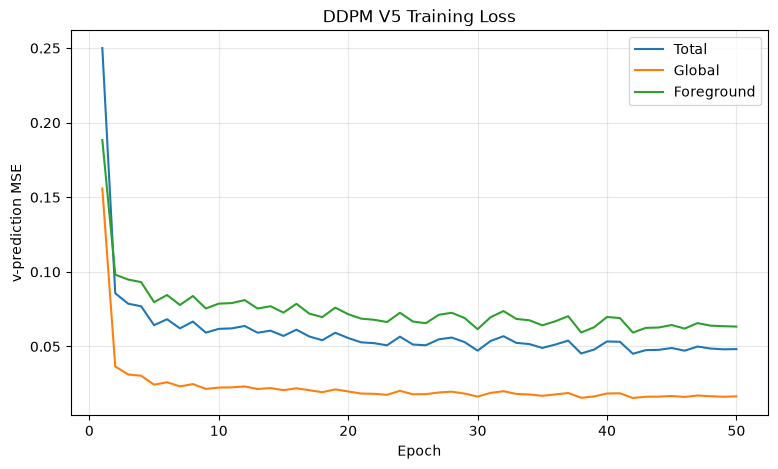

In [20]:
loss_history = np.load(
    "ddpm_v5_checkpoints/"
    "ddpm_v5_loss_history.npy"
)


print(
    "Number of epochs:",
    len(loss_history)
)


total_loss = (
    loss_history[:, 0]
)

global_loss = (
    loss_history[:, 1]
)

foreground_loss = (
    loss_history[:, 2]
)


for i in range(
    len(loss_history)
):
    print(
        f"Epoch {i + 1:03d} | "
        f"Total="
        f"{total_loss[i]:.6f} | "
        f"Global="
        f"{global_loss[i]:.6f} | "
        f"FG="
        f"{foreground_loss[i]:.6f}"
    )


plt.figure(
    figsize=(9, 5)
)

plt.plot(
    np.arange(
        1,
        len(loss_history) + 1
    ),
    total_loss,
    label="Total"
)

plt.plot(
    np.arange(
        1,
        len(loss_history) + 1
    ),
    global_loss,
    label="Global"
)

plt.plot(
    np.arange(
        1,
        len(loss_history) + 1
    ),
    foreground_loss,
    label="Foreground"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "v-prediction MSE"
)

plt.title(
    "DDPM V5 Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [21]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


model = UNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    time_dim=256
).to(device)


ema = EMA(
    model,
    decay=0.9999
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


loaded_epoch = load_checkpoint(
    model=model,
    ema=ema,
    optimizer=optimizer,
    path=(
        "ddpm_v5_checkpoints/"
        "ddpm_v5_epoch_050.pt"
    ),
    device=device
)


print(
    "Loaded V5 epoch:",
    loaded_epoch
)

Loaded V5 epoch: 50


In [22]:
torch.manual_seed(
    42
)


generated_v5 = sample_ddpm(
    model=ema.ema_model,
    shape=(
        1,
        1,
        208,
        224,
        160
    ),
    device=device
)


print(
    "Generated shape:",
    generated_v5.shape
)

print(
    "Generated min/max:",
    generated_v5.min().item(),
    generated_v5.max().item()
)

Generated shape: torch.Size([1, 1, 208, 224, 160])


Generated min/max: -1.0 1.0


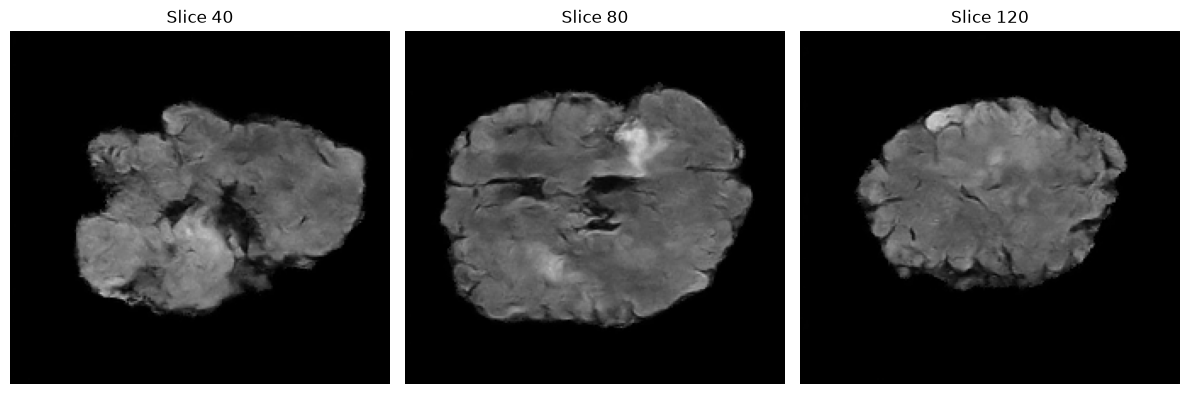

In [23]:
gen = (
    generated_v5[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)


gen_display = np.clip(
    (
        gen + 1.0
    )
    / 2.0,
    0.0,
    1.0
)


slices = [
    40,
    80,
    120
]


plt.figure(
    figsize=(12, 4)
)


for i, z_slice in enumerate(
    slices
):

    plt.subplot(
        1,
        3,
        i + 1
    )

    plt.imshow(
        gen_display[
            :,
            :,
            z_slice
        ],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        f"Slice {z_slice}"
    )

    plt.axis(
        "off"
    )


plt.tight_layout()

plt.show()

In [24]:
print(
    "Raw [-1,1] statistics"
)

print(
    "Min:",
    gen.min()
)

print(
    "Max:",
    gen.max()
)

print(
    "Mean:",
    gen.mean()
)

print(
    "Std:",
    gen.std()
)

print()

print(
    "Display [0,1] statistics"
)

print(
    "Min:",
    gen_display.min()
)

print(
    "Max:",
    gen_display.max()
)

print(
    "Mean:",
    gen_display.mean()
)

print(
    "Std:",
    gen_display.std()
)

print()

print(
    "P1:",
    np.percentile(
        gen_display,
        1
    )
)

print(
    "P50:",
    np.percentile(
        gen_display,
        50
    )
)

print(
    "P99:",
    np.percentile(
        gen_display,
        99
    )
)

Raw [-1,1] statistics
Min: -1.0
Max: 1.0
Mean: -0.79524237
Std: 0.3482054

Display [0,1] statistics
Min: 0.0
Max: 1.0
Mean: 0.102378845
Std: 0.17410271

P1: 0.0
P50: 0.00307858
P99: 0.5760828


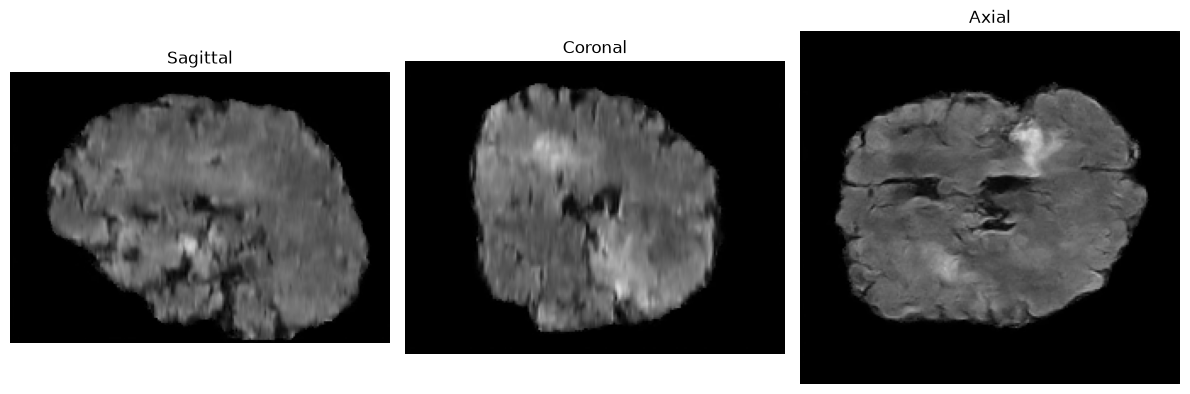

In [25]:
volume = gen_display

x_mid = (
    volume.shape[0] // 2
)

y_mid = (
    volume.shape[1] // 2
)

z_mid = (
    volume.shape[2] // 2
)

plt.figure(
    figsize=(12, 4)
)

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    volume[
        x_mid,
        :,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Sagittal"
)

plt.axis(
    "off"
)

plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    volume[
        :,
        y_mid,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Coronal"
)

plt.axis(
    "off"
)

plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    volume[
        :,
        :,
        z_mid
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Axial"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()